# main

In [700]:
melhor_geral = []

In [705]:
from engine_pso import executar_pso
from funcoes import sphere, rastrigin, rosenbrock

TOTAL_PARTICULAS = 250
ITERACOES_MAXIMAS = 600
C1 = 0.7
C2 = 1.8

DIMENSOES = 30

def menu():
    print("--- Algoritmo PSO ---")
    
    print("\nFunções disponíveis: 1-sphere, 2-rastrigin, 3-rosenbrock")
    escolha_f = input("Escolha o número da função: ")
    
    if escolha_f == "1":
        funcao_ativa = sphere
    elif escolha_f == "2":
        funcao_ativa = rastrigin
    else:
        funcao_ativa = rosenbrock

    print("\nTipos de inércia: 1-constante, 2-linear")
    escolha_i = input("Escolha o número da inércia: ")

    print("\nTipos de cooperação: 1-global, 2-local")
    escolha_c = input("Escolha o número da cooperação: ")

    print("\nExecutando o PSO... aguarde.")

    final, historico, historico_posicoes = executar_pso(
        funcao_ativa, 
        escolha_i, 
        escolha_c, 
        TOTAL_PARTICULAS, 
        DIMENSOES, 
        ITERACOES_MAXIMAS, 
        C1, 
        C2
    )

    print("\n--- Acompanhamento do Fitness ---")
    for i, valor in enumerate(historico, start=1):
        print(f"Iteração {i}: Melhor valor = {valor}")

    print("\n" + "="*40)
    print("Resultado final:", final)
    print("="*40)

    return historico, historico_posicoes, funcao_ativa,final

historico, historico_posicoes, funcao, final = menu()

melhor_geral.append(final)

--- Algoritmo PSO ---

Funções disponíveis: 1-sphere, 2-rastrigin, 3-rosenbrock

Tipos de inércia: 1-constante, 2-linear

Tipos de cooperação: 1-global, 2-local

Executando o PSO... aguarde.

--- Acompanhamento do Fitness ---
Iteração 1: Melhor valor = 366.44104856440634
Iteração 2: Melhor valor = 365.3639038811964
Iteração 3: Melhor valor = 365.3639038811964
Iteração 4: Melhor valor = 365.3639038811964
Iteração 5: Melhor valor = 357.63580978776355
Iteração 6: Melhor valor = 339.80004089956935
Iteração 7: Melhor valor = 335.93541584003606
Iteração 8: Melhor valor = 335.93541584003606
Iteração 9: Melhor valor = 335.93541584003606
Iteração 10: Melhor valor = 313.79615950807516
Iteração 11: Melhor valor = 311.8567900127962
Iteração 12: Melhor valor = 311.8567900127962
Iteração 13: Melhor valor = 311.8567900127962
Iteração 14: Melhor valor = 303.55195953606864
Iteração 15: Melhor valor = 303.55195953606864
Iteração 16: Melhor valor = 296.393003930056
Iteração 17: Melhor valor = 296.3930039

In [706]:
print(melhor_geral)
print(sum(melhor_geral)/len(melhor_geral))

[71.63671288412633, 87.55613954903458, 37.80839374591625, 90.54105729664039]
71.88557586892938


# Gráfico

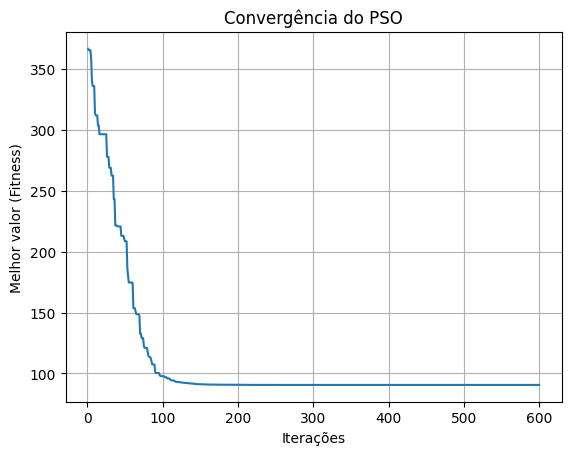

In [707]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(historico)+1), historico)
plt.xlabel("Iterações")
plt.ylabel("Melhor valor (Fitness)")
plt.title("Convergência do PSO")
plt.grid(True)
plt.show()

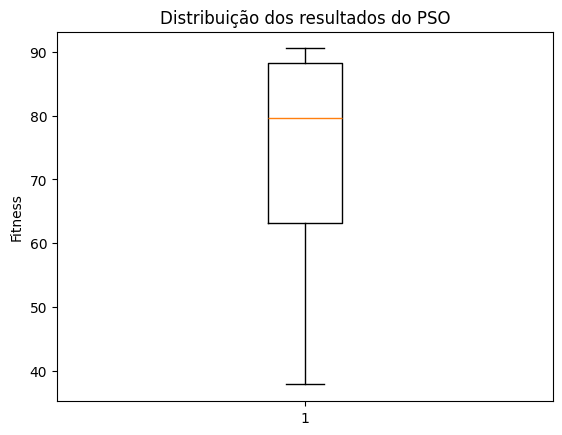

In [708]:
plt.boxplot(melhor_geral)

plt.title("Distribuição dos resultados do PSO")
plt.ylabel("Fitness")

plt.show()

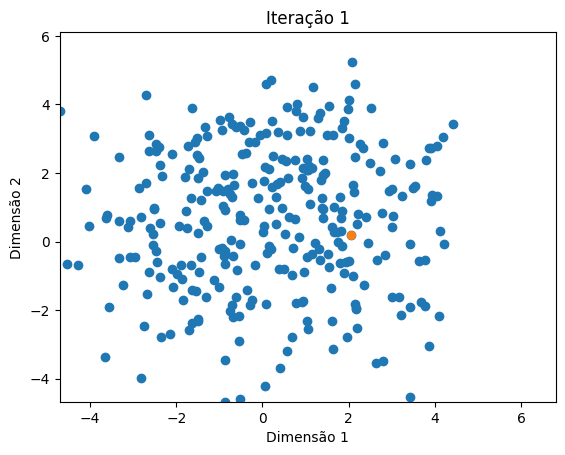

In [456]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
# calcula limites automaticamente
todos_x = []
todos_y = []

for frame in historico_posicoes:
    for p in frame:
        todos_x.append(p[0])
        todos_y.append(p[1])

xmin, xmax = min(todos_x), max(todos_x)
ymin, ymax = min(todos_y), max(todos_y)


fig, ax = plt.subplots()

def update(frame):
    ax.clear()
    
    posicoes = historico_posicoes[frame]
    
    x = [p[0] for p in posicoes]
    y = [p[1] for p in posicoes]
    
    # partículas
    ax.scatter(x, y)
    
    # melhor partícula
    melhor = min(posicoes, key=lambda p: funcao(p))
    ax.scatter(melhor[0], melhor[1], marker='.', s=120)
    
    # 🔥 usa limites corretos
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    ax.set_title(f"Iteração {frame+1}")
    ax.set_xlabel("Dimensão 1")
    ax.set_ylabel("Dimensão 2")

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(historico_posicoes),
    interval=300,
    repeat=True
)
HTML(ani.to_jshtml())1